In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import glob
from pathlib import Path
import os
import zipfile
import os
from shapely.geometry import Point

In [2]:
# Nepal Map: Shape Files
# Data Source: https://github.com/shravan-ghimire/NepalAdminGIS
boundary = gpd.read_file('data/Nepal Map/nepal_bnd_wgs84.shp') #national boundary, level 0
provinces = gpd.read_file('data/Nepal Map/nepal_province_wgs84.shp') #provincial boundry, level 1
districts = gpd.read_file('data/Nepal Map/nepal_districts_wgs84.shp') #district boundary, level 2
municipalities = gpd.read_file('data/Nepal Map/nepal_gapanapa_wgs84.shp') #municipal boundry, level 3
districts

,fid_1,FIRST_STAT,FIRST_DIST,FIRST_DCOD,Province,geometry
0,1,7.0,ACHHAM,69,Sudurpashchim,"POLYGON ((81.17111 29.38643, 81.17146 29.38629..."
1,2,5.0,ARGHAKHANCHI,51,Lumbini,"POLYGON ((83.0044 28.11188, 83.00485 28.11177,..."
2,3,4.0,BAGLUNG,45,Gandaki,"POLYGON ((83.09957 28.63442, 83.10086 28.63401..."
3,4,7.0,BAITADI,74,Sudurpashchim,"POLYGON ((80.75833 29.70446, 80.75852 29.70422..."
4,5,7.0,BAJHANG,68,Sudurpashchim,"POLYGON ((81.08994 30.05411, 81.09021 30.0541,..."
...,...,...,...,...,...,...
72,73,4.0,SYANGJA,39,Gandaki,"POLYGON ((83.80647 28.21943, 83.80666 28.21937..."
73,74,4.0,TANAHU,38,Gandaki,"POLYGON ((84.40063 28.12649, 84.40094 28.12637..."
74,75,1.0,TAPLEJUNG,1,Koshi,"POLYGON ((87.83403 27.95158, 87.83465 27.95139..."
75,76,1.0,TERHATHUM,8,Koshi,"POLYGON ((87.5355 27.29116, 87.53626 27.29104,..."


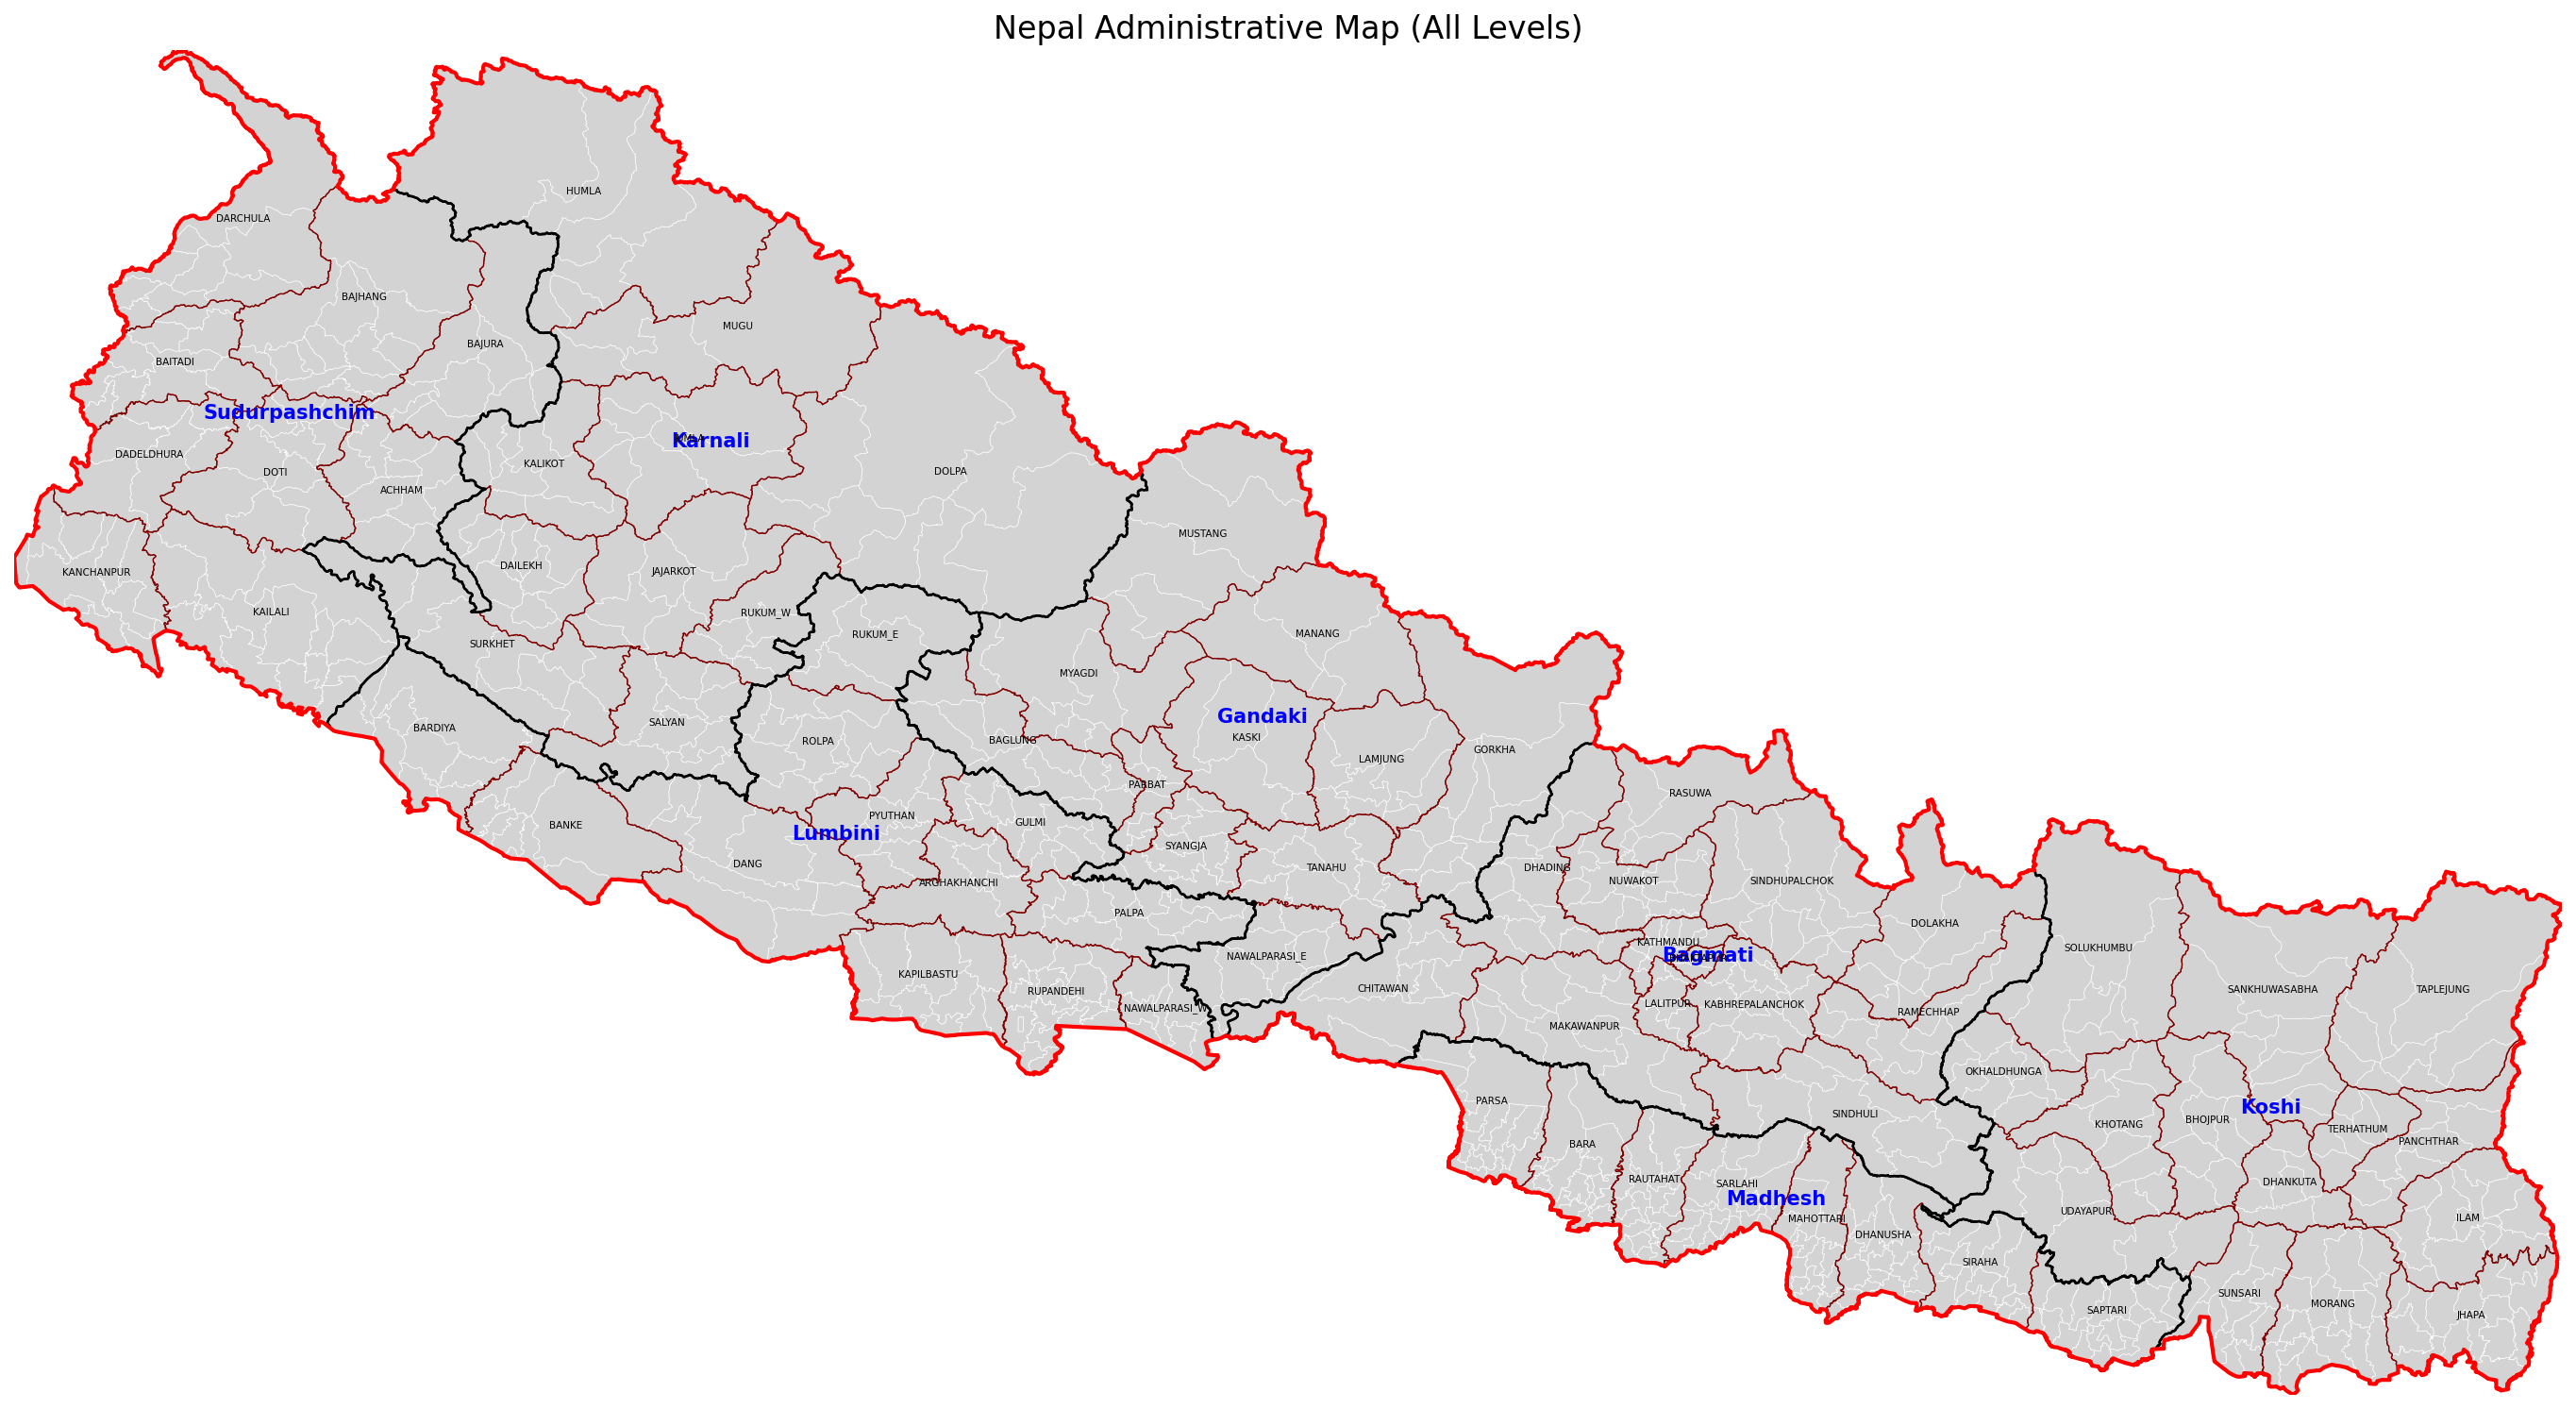

In [3]:
plt.rcParams['figure.dpi'] = 150

fig, ax = plt.subplots(figsize=(18, 10))

municipalities.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
districts.plot(ax=ax, facecolor='none', edgecolor='maroon', linewidth=0.6)
provinces.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2)
boundary.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# Province labels
for idx, row in provinces.iterrows():
    ax.annotate(
        text=row['Province'],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=10,
        fontweight='bold',
        color='blue',
        ha='center'
    )

# District labels
for idx, row in districts.iterrows():
    ax.annotate(
        text=row['FIRST_DIST'],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=5,
        color='black',
        ha='center'
    )

minx, miny, maxx, maxy = boundary.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_aspect('auto')
ax.margins(0)

fig.subplots_adjust(left=0, right=1, top=0.95, bottom=0)
ax.set_title("Nepal Administrative Map (All Levels)", fontsize=16)
ax.grid(True, linestyle='--', linewidth=0.3, alpha=0.5)
ax.set_axis_off()
plt.show()

In [4]:
# Overall Fire incidents dataset: 2020-2024
# Source: MODISS
shp_files = list(Path("data/Fire Incidents/").glob("*/*.shp"))

shp_files = [f for f in shp_files if not f.name.startswith("._")]

fire_data_list = []

for file in shp_files:
    try:
        gdf = gpd.read_file(file)
        
        year = file.parent.name
        gdf['year'] = int(year)
        
        fire_data_list.append(gdf)
    
    except Exception as e:
        print(f"Skipping file: {file} → {e}")

fires = gpd.GeoDataFrame(pd.concat(fire_data_list, ignore_index=True))

fires.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,year
0,26.90225,85.80494,328.11,0.40,0.37,2020-01-02,0729,N20,VIIRS,n,2,290.10,2.20,D,0,POINT (85.80494 26.90225),2020
1,27.47337,84.33176,328.18,0.38,0.36,2020-01-02,0729,N20,VIIRS,n,2,291.14,2.03,D,0,POINT (84.33176 27.47337),2020
2,27.47309,82.85561,327.18,0.40,0.37,2020-01-02,0729,N20,VIIRS,n,2,293.35,2.15,D,0,POINT (82.85561 27.47309),2020
3,28.77123,80.20963,337.18,0.49,0.49,2020-01-05,0814,N20,VIIRS,n,2,290.54,6.05,D,0,POINT (80.20963 28.77123),2020
4,27.62135,83.08981,295.71,0.42,0.38,2020-01-06,2020,N20,VIIRS,n,2,277.86,0.42,N,0,POINT (83.08981 27.62135),2020


In [10]:
# Nepal Forest Cover Dataset: Modis 2020-2024
file_path = "data/Forest Cover.xlsx"
forest_cover = pd.read_excel(file_path)
forest_cover.head()

,S.NO,District,mean_slope_percent,Population Density,Road Density (Km/100 Km2),Rainfall 2020 mm,Forest Cover,Year
0,1,ACHHAM,55.410044,136.221429,7.51,1334.4,2.326786,2020
1,2,ARGHAKHANCHI,46.532218,148.437552,24.43,1775.4,0.568315,2020
2,3,BAGLUNG,62.384511,139.692265,12.55,2011.0,1.299327,2020
3,4,BAITADI,58.269744,159.418697,10.78,1501.8,0.809085,2020
4,5,BAJHANG,69.153910,55.255698,3.17,1366.0,5.914670,2020


In [5]:
# Nepal Forest Cover: 2020-2022 ICIMOD
import rasterio

raster_paths = {
    2020: "data/Land Cover/2020/lc2020.tif",
    2021: "data/Land Cover/2021/lc2021.tif",
    2022: "data/Land Cover/2022/lc2022.tif" 
}

raster = rasterio.open(raster_paths[2022])

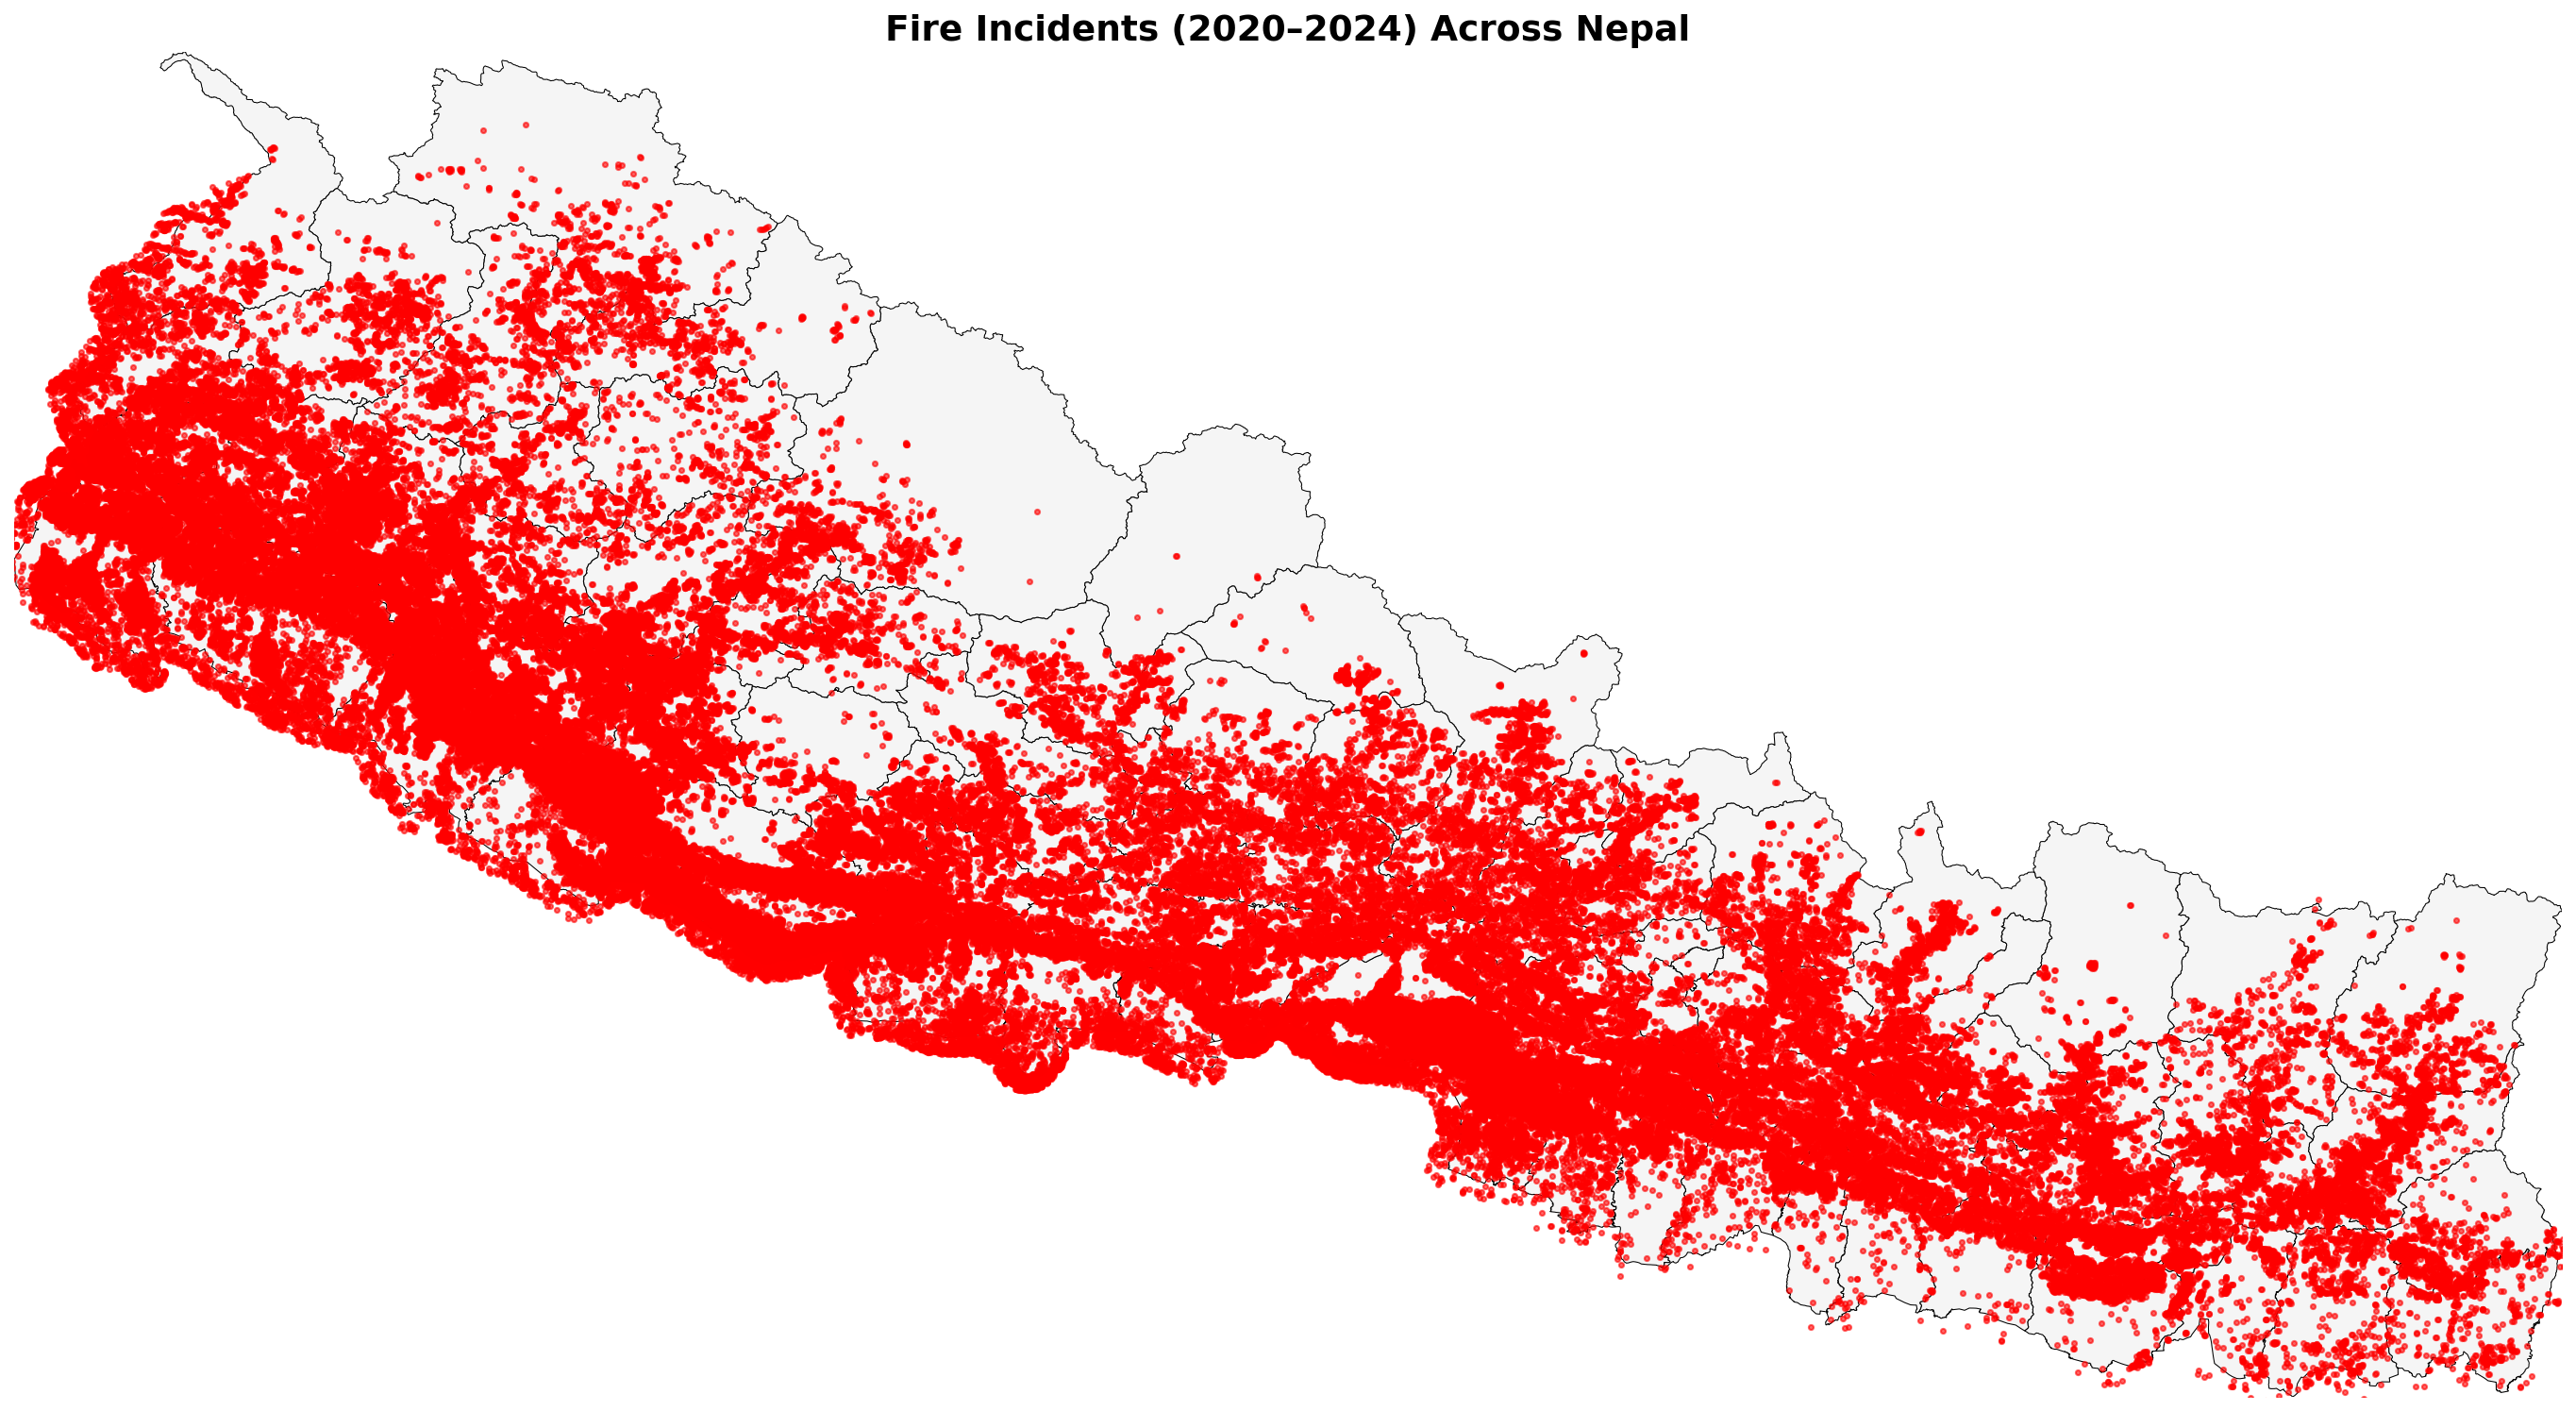

In [6]:
# Fire Incidents
plt.rcParams['figure.dpi'] = 150  

fig, ax = plt.subplots(figsize=(18, 10))  # control size HERE only

# Plot base map
districts.plot(
    ax=ax,
    color='whitesmoke',
    edgecolor='black',
    linewidth=0.5
)

# Plot fire points
fires.plot(
    ax=ax,
    markersize=6,
    color='red',
    alpha=0.6,
    marker='o'
)

minx, miny, maxx, maxy = boundary.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect('auto')
ax.margins(0)

# Titles
ax.set_title(
    "Fire Incidents (2020–2024) Across Nepal",
    fontsize=18,
    fontweight='bold'
)

ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, top=0.95, bottom=0)

plt.show()

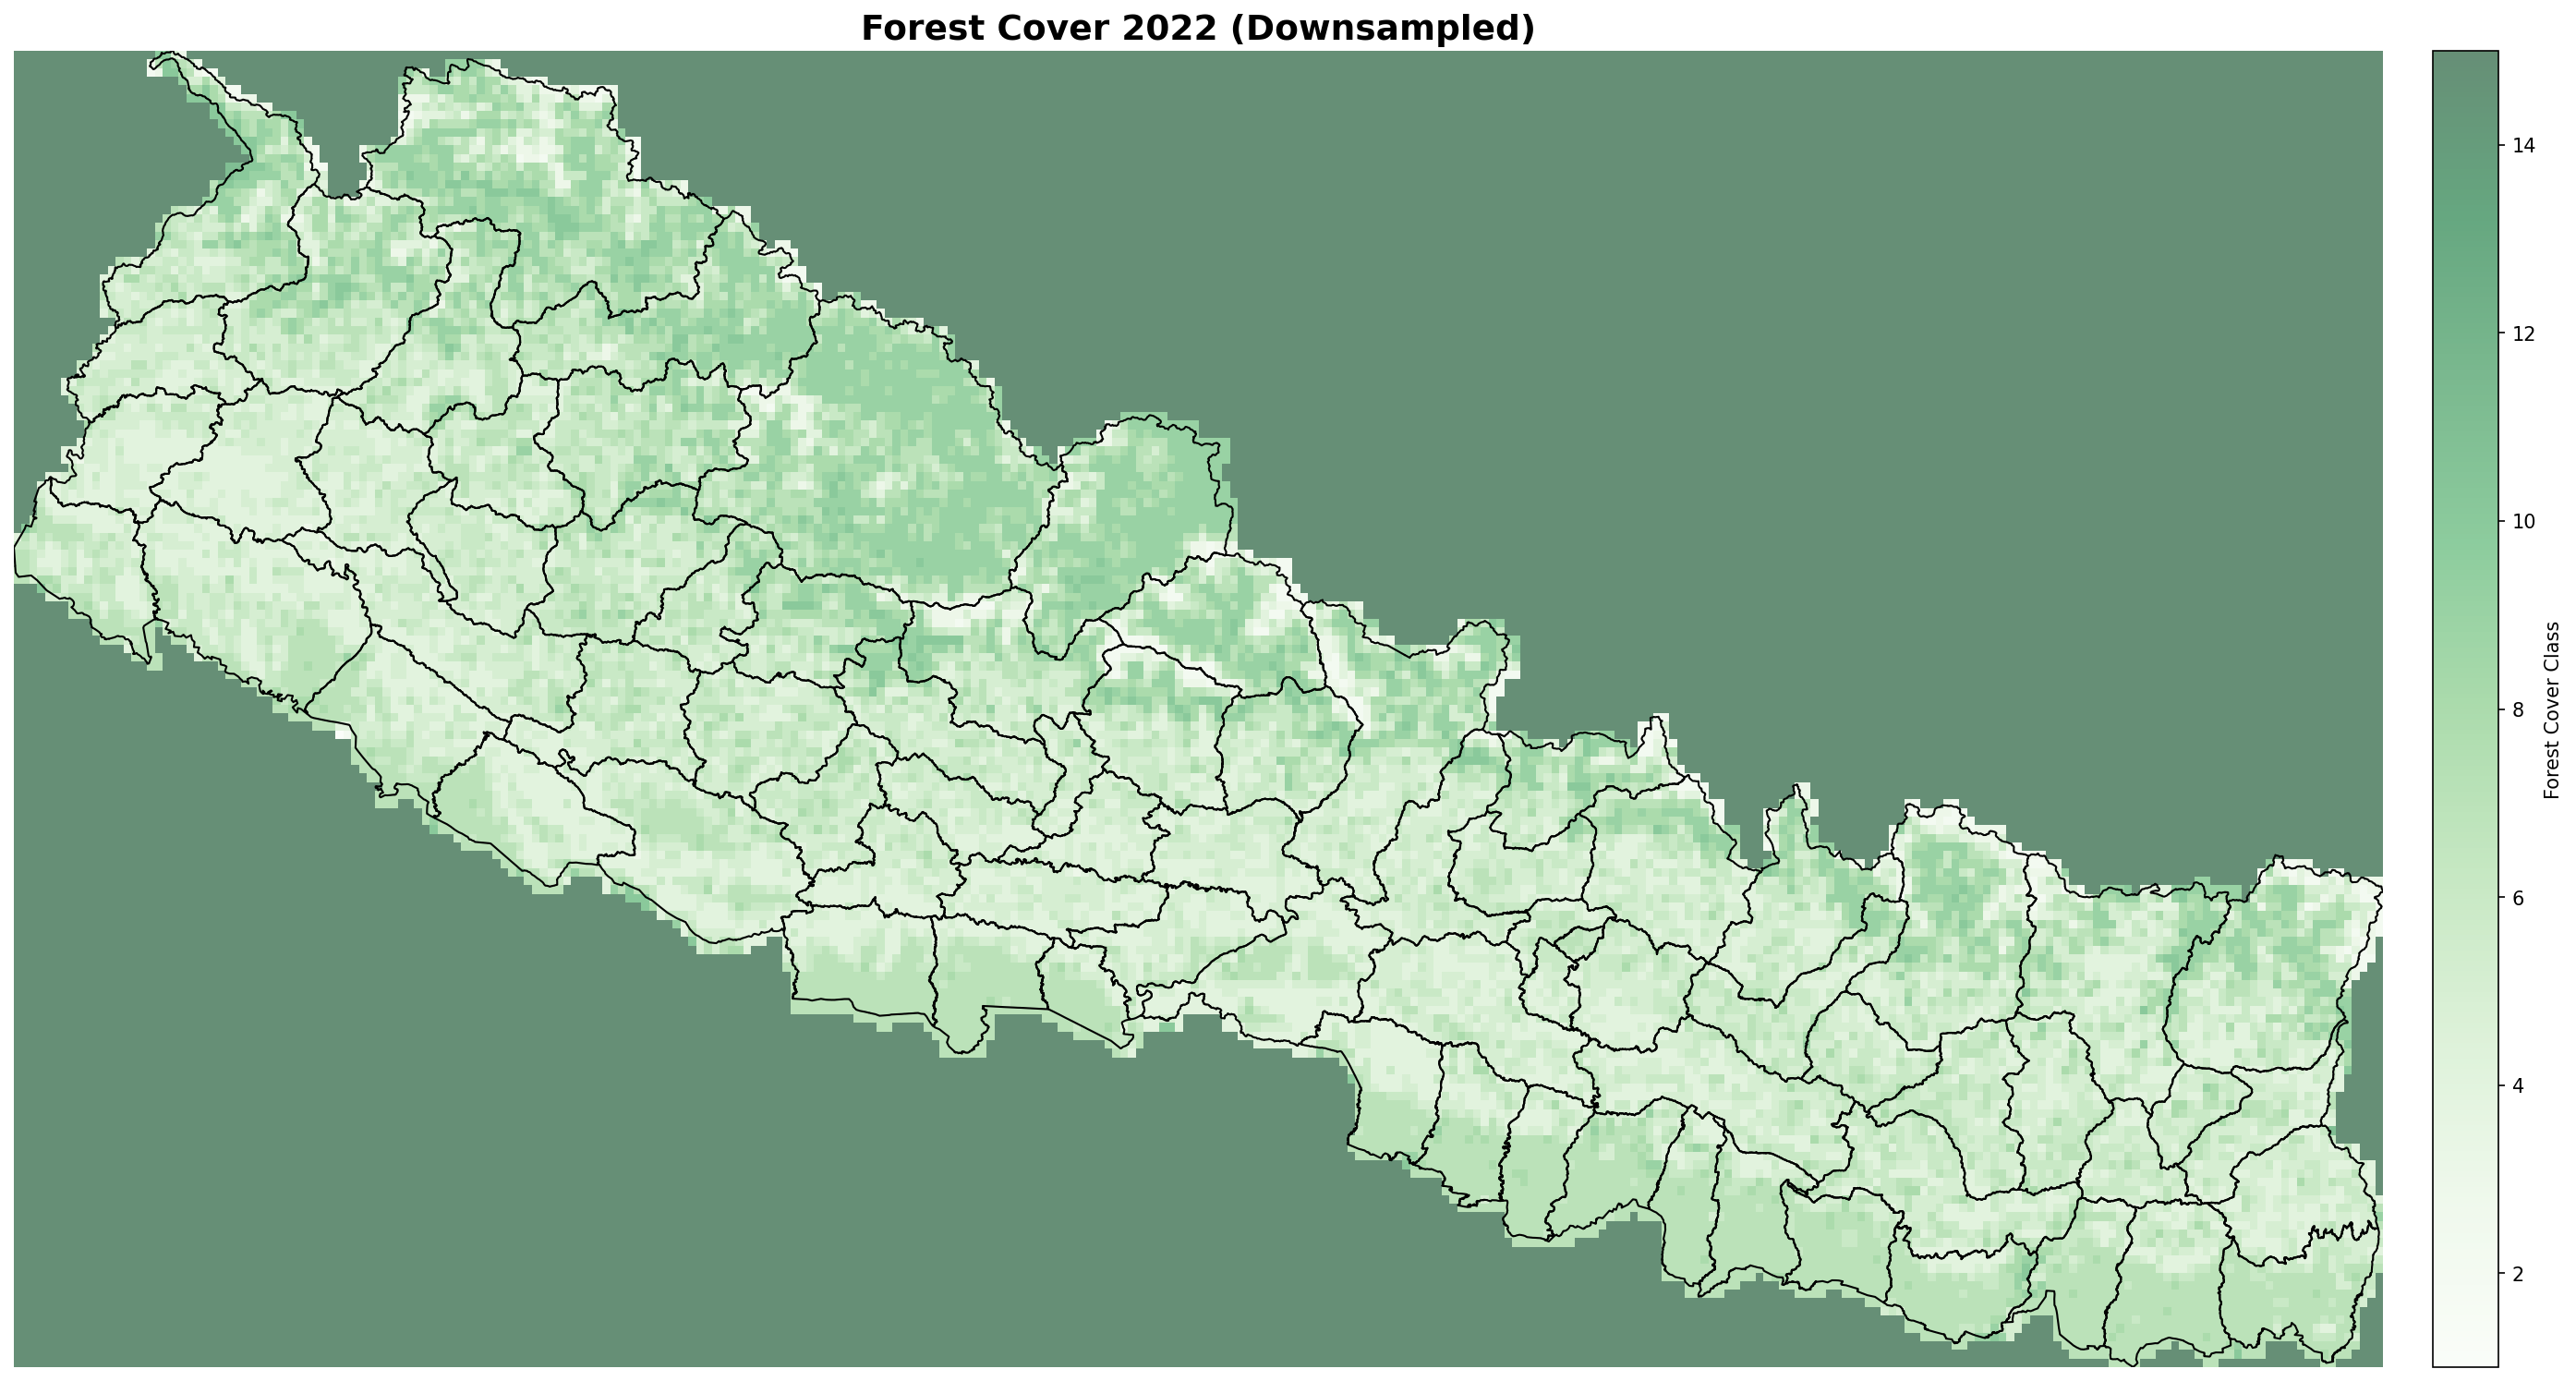

In [7]:
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

with rasterio.open("data/Land Cover/2022/lc2022.tif") as src:
    factor = 0.01
    new_width = int(src.width * factor)
    new_height = int(src.height * factor)
    
    forest_small = src.read(
        1,
        out_shape=(new_height, new_width),
        resampling=Resampling.bilinear
    )
    
    transform = src.transform * src.transform.scale(
        src.width / new_width,
        src.height / new_height
    )

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(18, 10))

# forest cover
extent = (
    transform[2],
    transform[2] + transform[0] * new_width,
    transform[5] + transform[4] * new_height,
    transform[5]
)

im = ax.imshow(
    forest_small,
    extent=extent,
    cmap='Greens',
    alpha=0.6
)

# Overlay Nepal boundary
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
minx, miny, maxx, maxy = districts.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_aspect('auto')
ax.margins(0)

# Clean layout
fig.subplots_adjust(left=0, right=1, top=0.95, bottom=0)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Forest Cover Class')
ax.set_title("Forest Cover 2022 (Downsampled)", fontsize=18, fontweight='bold')
ax.set_axis_off()

plt.show()

In [8]:
# CRS consistency – ensuring all spatial data use the same coordinate
fires = fires.to_crs('EPSG:4326')
districts = districts.to_crs('EPSG:4326')
fires_proj = fires.to_crs(raster.crs)

In [ ]:
# Extract land cover code at each fire point
def extract_code(geom, raster):
    x, y = geom.x, geom.y
    try:
        r, c = raster.index(x, y)
        if 0 <= r < raster.height and 0 <= c < raster.width:
            return raster.read(1)[r, c]
        else:
            return -9999
    except:
        return -9999

landcover_codes = []
for _, row in fires_proj.iterrows():
    code = extract_code(row.geometry, raster)
    landcover_codes.append(code)

fires_raw['landcover_code'] = landcover_codes

In [ ]:
forest_fires = forest_fires.to_crs(districts.crs)
forest_fires_with_district = gpd.sjoin(forest_fires, districts, how='inner', predicate='within')
forest_fires_with_district.head()
print("hello")